In [1]:
import numpy as np
import math

from pyparsing import col

In [3]:
L, d_k, d_v = 4, 8, 8
q = np.random.randn(L, d_k)
k = np.random.randn(L, d_k)
v = np.random.randn(L, d_v)

In [4]:
print("Q\n", q)
print("K\n", k)
print("V\n", v)

Q
 [[ 0.30144008 -0.50099233  0.94877014  0.28954789 -0.75341411  0.53341479
   0.79056167  0.29179788]
 [ 0.71908972 -0.82536138  0.49345838  1.936317   -1.41590758 -1.01076807
   0.75650858 -0.90015113]
 [-2.19974278 -0.06003805 -0.96092038  0.39073052  1.00785204  0.41598755
  -0.09778216 -0.48669123]
 [-1.10682884 -0.94308775  1.26017158  0.45808073 -1.74643546 -0.07881837
   0.4368044  -0.52656392]]
K
 [[-0.79310936  0.82058683 -0.22402003 -0.16044056 -0.26463714 -0.1358666
  -0.45053219  0.66374411]
 [-0.42136526 -1.37549349 -0.62528819  1.833795    1.3880717   0.62305605
   0.35805489  0.57020049]
 [ 0.75678533 -0.20546363  1.83068452 -0.71238909 -1.01230817 -0.11552146
   0.744152    0.1697279 ]
 [-1.21377808 -0.81690736 -0.33171837 -0.78641147  0.62468746  0.08839061
  -0.50393021  1.43750581]]
V
 [[-0.19975345 -1.66146933  1.02875949 -1.1468623  -0.06099658 -2.57644877
   2.70143331  2.52448359]
 [-1.65949121 -1.48787276  1.66119382 -0.57654949  1.33632344  0.99039534
  -0.68

In [5]:
np.matmul(q, k.T)

array([[-0.94476765,  0.23581429,  3.20057988, -0.90147156],
       [-2.09507594,  1.2369931 ,  2.19801064, -4.53404477],
       [ 1.24572822,  3.67248045, -4.91357388,  2.74654089],
       [-0.32526514, -0.80148693,  3.34949566, -0.73940285]])

In [6]:
q.var(), k.var(), np.matmul(q, k.T).var()

(np.float64(0.8459453782534992),
 np.float64(0.6964725590795177),
 np.float64(6.382502454742739))

In [7]:
scaled = np.matmul(q, k.T) / math.sqrt(d_k)
q.var(), k.var(), scaled.var()

(np.float64(0.8459453782534992),
 np.float64(0.6964725590795177),
 np.float64(0.7978128068428423))

In [8]:
scaled

array([[-0.33402581,  0.08337294,  1.13157587, -0.31871833],
       [-0.7407212 ,  0.43734311,  0.77711411, -1.6030269 ],
       [ 0.44043143,  1.29841792, -1.73721071,  0.97104885],
       [-0.11499859, -0.28336842,  1.18422555, -0.26141838]])

In [9]:
mask = np.tril(np.ones((L,L)))
mask

array([[1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 0.],
       [1., 1., 1., 1.]])

In [11]:
mask[mask == 0] = -np.inf
mask[mask == 1] = 0

In [12]:
mask

array([[  0., -inf, -inf, -inf],
       [  0.,   0., -inf, -inf],
       [  0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.]])

In [13]:
scaled + mask

array([[-0.33402581,        -inf,        -inf,        -inf],
       [-0.7407212 ,  0.43734311,        -inf,        -inf],
       [ 0.44043143,  1.29841792, -1.73721071,        -inf],
       [-0.11499859, -0.28336842,  1.18422555, -0.26141838]])

In [14]:
def softmax(x):
    return (np.exp(x).T/ np.sum(np.exp(x), axis = -1)).T

In [15]:
attention = softmax(scaled + mask)

In [16]:
attention

array([[1.        , 0.        , 0.        , 0.        ],
       [0.23540042, 0.76459958, 0.        , 0.        ],
       [0.28804203, 0.6793204 , 0.03263758, 0.        ],
       [0.15685568, 0.13254952, 0.57510365, 0.13549115]])

In [17]:
new_v = np.matmul(attention, v)
new_v

array([[-0.19975345, -1.66146933,  1.02875949, -1.1468623 , -0.06099658,
        -2.57644877,  2.70143331,  2.52448359],
       [-1.31586833, -1.52873747,  1.51231851, -0.71080136,  1.00739372,
         0.15075875,  0.10943956,  0.4732455 ],
       [-1.22181274, -1.53512985,  1.42239451, -0.72385327,  0.87906609,
        -0.02273834,  0.36754647,  0.68059476],
       [-0.74839924, -1.19428058,  0.34067506, -0.18931965, -0.09909329,
         0.60227205,  1.17453631,  1.48738555]])

In [18]:
v

array([[-0.19975345, -1.66146933,  1.02875949, -1.1468623 , -0.06099658,
        -2.57644877,  2.70143331,  2.52448359],
       [-1.65949121, -1.48787276,  1.66119382, -0.57654949,  1.33632344,
         0.99039534, -0.68856822, -0.1582776 ],
       [-1.13210393, -1.40373594, -0.07397297, -0.05658811, -0.34181756,
         1.42753959,  1.75192464,  1.86774243],
       [ 1.13642173,  0.52284445,  0.01225154,  0.73464278, -0.51718604,
         0.3996055 , -1.22124363,  0.28223317]])

In [19]:
def softmax(x):
    return (np.exp(x).T/ np.sum(np.exp(x), axis = -1)).T

def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.shape[-1]
    scaled = np.matmul(q, k.T) / math.sqrt(d_k)
    if mask is not None:
        scaled = scaled + mask
    attention = softmax(scaled)
    out = np.matmul(attention, v)
    return out, attention

In [21]:
values, attention = scaled_dot_product_attention(q,k,v,mask=mask)
print("Q\n", q)
print("K\n", k)
print("V\n", v)
print("New_V\n", values)
print("Attention\n", attention)

Q
 [[ 0.30144008 -0.50099233  0.94877014  0.28954789 -0.75341411  0.53341479
   0.79056167  0.29179788]
 [ 0.71908972 -0.82536138  0.49345838  1.936317   -1.41590758 -1.01076807
   0.75650858 -0.90015113]
 [-2.19974278 -0.06003805 -0.96092038  0.39073052  1.00785204  0.41598755
  -0.09778216 -0.48669123]
 [-1.10682884 -0.94308775  1.26017158  0.45808073 -1.74643546 -0.07881837
   0.4368044  -0.52656392]]
K
 [[-0.79310936  0.82058683 -0.22402003 -0.16044056 -0.26463714 -0.1358666
  -0.45053219  0.66374411]
 [-0.42136526 -1.37549349 -0.62528819  1.833795    1.3880717   0.62305605
   0.35805489  0.57020049]
 [ 0.75678533 -0.20546363  1.83068452 -0.71238909 -1.01230817 -0.11552146
   0.744152    0.1697279 ]
 [-1.21377808 -0.81690736 -0.33171837 -0.78641147  0.62468746  0.08839061
  -0.50393021  1.43750581]]
V
 [[-0.19975345 -1.66146933  1.02875949 -1.1468623  -0.06099658 -2.57644877
   2.70143331  2.52448359]
 [-1.65949121 -1.48787276  1.66119382 -0.57654949  1.33632344  0.99039534
  -0.68

MultiHead

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [21]:
sequence_length = 4
batch_size = 1
input_dim = 512
d_model = 512
x= torch.randn((batch_size, sequence_length, input_dim))

In [22]:
x.size()

torch.Size([1, 4, 512])

In [23]:
qkv_layer = nn.Linear(input_dim, 3 * d_model)

In [24]:
qkv = qkv_layer(x)

In [25]:
qkv.shape

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'qkv distribution')

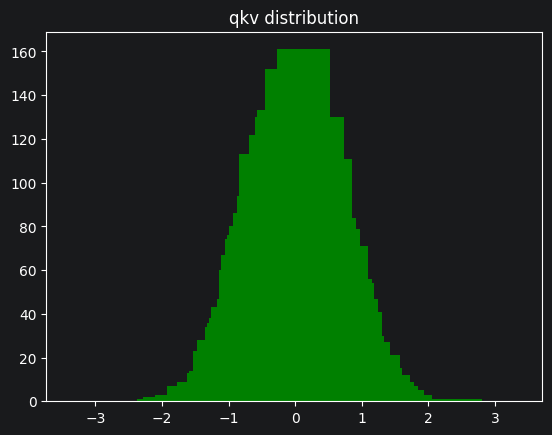

In [26]:
y_val = torch.histc(qkv, bins=200, min=-3, max=3)
x_val = np.arange(-1,1,0.01)*3
plt.bar(x_val, y_val,align='center',color='green')
plt.title('qkv distribution')

In [27]:
num_heads = 8
head_dim = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [28]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [29]:
qkv = qkv.permute(0,2,1,3)
qkv.shape

torch.Size([1, 8, 4, 192])

In [30]:
q, k, v = qkv.chunk(3, dim=-1)
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

In [31]:
d_k = q.size()[-1]
scaled = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])

In [32]:
k.T.shape

torch.Size([64, 4, 8, 1])

In [33]:
y = torch.randn(2,3)
torch.transpose(y,0,1)

tensor([[ 0.2108, -0.4838],
        [-0.3848, -0.5223],
        [ 1.4006, -0.4929]])

In [34]:
torch.transpose(y,1,0)

tensor([[ 0.2108, -0.4838],
        [-0.3848, -0.5223],
        [ 1.4006, -0.4929]])

In [35]:
k.transpose(-1, -2) == k.transpose(-2, -1)

tensor([[[[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         ...,

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, 

In [36]:
k.transpose(-1, -2).shape

torch.Size([1, 8, 64, 4])

In [37]:
mask = torch.full(scaled.size(), float('-inf'))
mask = torch.triu(mask, diagonal=1)
mask[0][1]

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [38]:
(scaled+mask)[0][0]

tensor([[-0.2300,    -inf,    -inf,    -inf],
        [ 0.1200,  0.2372,    -inf,    -inf],
        [ 0.5110, -0.1413,  0.1964,    -inf],
        [ 0.1989, -0.1791, -0.4828, -0.3513]], grad_fn=<SelectBackward0>)

In [39]:
scaled += mask

In [40]:
np.exp(0.5596) / (np.exp(0.5596) + np.exp(0.0404))

np.float64(0.6269606805367254)

In [41]:
attention = F.softmax(scaled, dim=-1)

In [42]:
attention.shape

torch.Size([1, 8, 4, 4])

In [43]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4708, 0.5292, 0.0000, 0.0000],
        [0.4443, 0.2314, 0.3243, 0.0000],
        [0.3613, 0.2476, 0.1827, 0.2084]], grad_fn=<SelectBackward0>)

In [44]:
values = torch.matmul(attention, v)
values.shape

torch.Size([1, 8, 4, 64])

In [45]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1,-2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

In [49]:
values, attention = scaled_dot_product(q,k,v,mask=mask)

In [50]:
attention.shape

torch.Size([1, 8, 4, 4])

In [51]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4708, 0.5292, 0.0000, 0.0000],
        [0.4443, 0.2314, 0.3243, 0.0000],
        [0.3613, 0.2476, 0.1827, 0.2084]], grad_fn=<SelectBackward0>)

In [52]:
values.size()

torch.Size([1, 8, 4, 64])

In [53]:
values = values.reshape(batch_size, sequence_length, num_heads* head_dim)
values.size()

torch.Size([1, 4, 512])

In [54]:
linear_layer = nn.Linear(d_model, d_model)

In [55]:
out = linear_layer(values)

In [56]:
out.shape

torch.Size([1, 4, 512])

In [57]:
out

tensor([[[-0.1751,  0.1681,  0.1566,  ..., -0.0230, -0.1294, -0.1511],
         [ 0.3067,  0.0657, -0.0316,  ...,  0.3752, -0.0304,  0.0619],
         [ 0.0034,  0.0452,  0.1939,  ...,  0.1526, -0.0403, -0.3176],
         [ 0.2969, -0.2287,  0.3743,  ..., -0.0815, -0.5713, -0.1326]]],
       grad_fn=<ViewBackward0>)

Positional Encoding

In [4]:
max_sequence_length = 10
d_model = 6

In [5]:
even_i = torch.arange(0, d_model,2).float()
even_i

tensor([0., 2., 4.])

In [6]:
even_denominator = torch.pow(10000, even_i/d_model)
even_denominator

tensor([  1.0000,  21.5443, 464.1590])

In [7]:
odd_i = torch.arange(1, d_model,2).float()
odd_i

tensor([1., 3., 5.])

In [8]:
even_denominator = torch.pow(10000, (odd_i -1)/d_model)
even_denominator

tensor([  1.0000,  21.5443, 464.1590])

In [9]:
denominator = even_denominator

In [10]:
position = torch.arange(max_sequence_length,dtype=torch.float).reshape(max_sequence_length,1)

In [11]:
position

tensor([[0.],
        [1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])

In [12]:
even_PE = torch.sin(position/denominator)
odd_PE = torch.cos(position/denominator)

In [13]:
even_PE

tensor([[ 0.0000,  0.0000,  0.0000],
        [ 0.8415,  0.0464,  0.0022],
        [ 0.9093,  0.0927,  0.0043],
        [ 0.1411,  0.1388,  0.0065],
        [-0.7568,  0.1846,  0.0086],
        [-0.9589,  0.2300,  0.0108],
        [-0.2794,  0.2749,  0.0129],
        [ 0.6570,  0.3192,  0.0151],
        [ 0.9894,  0.3629,  0.0172],
        [ 0.4121,  0.4057,  0.0194]])

In [14]:
even_PE.shape

torch.Size([10, 3])

In [15]:
odd_PE

tensor([[ 1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.9989,  1.0000],
        [-0.4161,  0.9957,  1.0000],
        [-0.9900,  0.9903,  1.0000],
        [-0.6536,  0.9828,  1.0000],
        [ 0.2837,  0.9732,  0.9999],
        [ 0.9602,  0.9615,  0.9999],
        [ 0.7539,  0.9477,  0.9999],
        [-0.1455,  0.9318,  0.9999],
        [-0.9111,  0.9140,  0.9998]])

In [16]:
odd_PE.shape

torch.Size([10, 3])

In [17]:
stacked = torch.stack([even_PE, odd_PE], dim=2)
stacked.shape

torch.Size([10, 3, 2])

In [18]:
PE = torch.flatten(stacked, start_dim=1, end_dim=2)
PE

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957,  0.0043,  1.0000],
        [ 0.1411, -0.9900,  0.1388,  0.9903,  0.0065,  1.0000],
        [-0.7568, -0.6536,  0.1846,  0.9828,  0.0086,  1.0000],
        [-0.9589,  0.2837,  0.2300,  0.9732,  0.0108,  0.9999],
        [-0.2794,  0.9602,  0.2749,  0.9615,  0.0129,  0.9999],
        [ 0.6570,  0.7539,  0.3192,  0.9477,  0.0151,  0.9999],
        [ 0.9894, -0.1455,  0.3629,  0.9318,  0.0172,  0.9999],
        [ 0.4121, -0.9111,  0.4057,  0.9140,  0.0194,  0.9998]])

Normalization

In [19]:
inputs = torch.Tensor([[[0.2, 0.1, 0.3], [0.5, 0.1, 0.1]]])
B, S, E = inputs.size()
inputs = inputs.reshape(S, B, E)
inputs.size()

torch.Size([2, 1, 3])

In [20]:
parameter_shape = inputs.size()[-2:]
gamma = nn.Parameter(torch.ones(parameter_shape))
beta =  nn.Parameter(torch.zeros(parameter_shape))

In [21]:
gamma.size(), beta.size()

(torch.Size([1, 3]), torch.Size([1, 3]))

In [22]:
dims = [-(i + 1) for i in range(len(parameter_shape))]

In [23]:
dims

[-1, -2]

In [24]:
mean = inputs.mean(dim=dims, keepdim=True)
mean.size()

torch.Size([2, 1, 1])

In [25]:
mean

tensor([[[0.2000]],

        [[0.2333]]])

In [26]:
var = ((inputs - mean) ** 2).mean(dim=dims, keepdim=True)
epsilon = 1e-5
std = (var + epsilon).sqrt()
std

tensor([[[0.0817]],

        [[0.1886]]])

In [27]:
y = (inputs - mean) / std
y

tensor([[[ 0.0000, -1.2238,  1.2238]],

        [[ 1.4140, -0.7070, -0.7070]]])

In [28]:
out = gamma * y + beta

In [29]:
out

tensor([[[ 0.0000, -1.2238,  1.2238]],

        [[ 1.4140, -0.7070, -0.7070]]], grad_fn=<AddBackward0>)

In [30]:
out[0].mean(), out[0].std()

(tensor(3.9736e-08, grad_fn=<MeanBackward0>),
 tensor(1.2238, grad_fn=<StdBackward0>))